
## Text Generation using **Vanilla RNN, LSTM, and GRU**


#  Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = """
To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles,
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in that sleep of death what dreams may come,
When we have shuffled off this mortal coil,
Must give us pause. There's the respect
That makes calamity of so long life.

All the world's a stage,
And all the men and women merely players;
They have their exits and their entrances;
And one man in his time plays many parts,
His acts being seven ages. At first the infant,
Mewling and puking in the nurse's arms.
Then the whining schoolboy, with his satchel
And shining morning face, creeping like snail
Unwillingly to school. And then the lover,
Sighing like furnace, with a woeful ballad
Made to his mistress' eyebrow.

Some are born great,
Some achieve greatness,
And some have greatness thrust upon them.

The course of true love never did run smooth.

Love looks not with the eyes, but with the mind;
And therefore is winged Cupid painted blind.

If music be the food of love, play on;
Give me excess of it, that surfeiting,
The appetite may sicken, and so die.

Cowards die many times before their deaths;
The valiant never taste of death but once.

What's in a name?
That which we call a rose
By any other word would smell as sweet.
"""
print(corpus)


To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles,
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in that sleep of death what dreams may come,
When we have shuffled off this mortal coil,
Must give us pause. There's the respect
That makes calamity of so long life.

All the world's a stage,
And all the men and women merely players;
They have their exits and their entrances;
And one man in his time plays many parts,
His acts being seven ages. At first the infant,
Mewling and puking in the nurse's arms.
Then the whining schoolboy, with his satchel
And shining morning face, creeping like snail
Unwillingly to school. And then the lover,
Sighing like furnac

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 177
X shape: (251, 9)
y shape: (251,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
# Baseline: 100 epochs (original requirement)
rnn_model_100 = Sequential([
    Embedding(total_words, 100),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model_100.build(input_shape=(None, max_len-1))
rnn_model_100.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history_100 = rnn_model_100.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN (100 epochs) training completed")

# Upgraded: 200 epochs (student task)
rnn_model = Sequential([
    Embedding(total_words, 100),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model.build(input_shape=(None, max_len-1))
rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN (200 epochs) training completed")

2026-06-28 13:46:01.831068: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-28 13:46:01.831138: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-28 13:46:01.831146: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-28 13:46:01.831351: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-28 13:46:01.831372: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-06-28 13:46:03.341045: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Vanilla RNN (100 epochs) training completed
Vanilla RNN (200 epochs) training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
# Baseline: 100 epochs
lstm_model_100 = Sequential([
    Embedding(total_words, 100),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model_100.build(input_shape=(None, max_len-1))
lstm_model_100.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history_100 = lstm_model_100.fit(X, y, epochs=100, verbose=0)
print("LSTM (100 epochs) training completed")

# Upgraded: 200 epochs
lstm_model = Sequential([
    Embedding(total_words, 100),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.build(input_shape=(None, max_len-1))
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM (200 epochs) training completed")

LSTM (100 epochs) training completed
LSTM (200 epochs) training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
# Baseline: 100 epochs
gru_model_100 = Sequential([
    Embedding(total_words, 100),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model_100.build(input_shape=(None, max_len-1))
gru_model_100.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history_100 = gru_model_100.fit(X, y, epochs=100, verbose=0)
print("GRU (100 epochs) training completed")

# Upgraded: 200 epochs
gru_model = Sequential([
    Embedding(total_words, 100),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.build(input_shape=(None, max_len-1))
gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU (200 epochs) training completed")

GRU (100 epochs) training completed
GRU (200 epochs) training completed


## 📉 Compare Training Loss

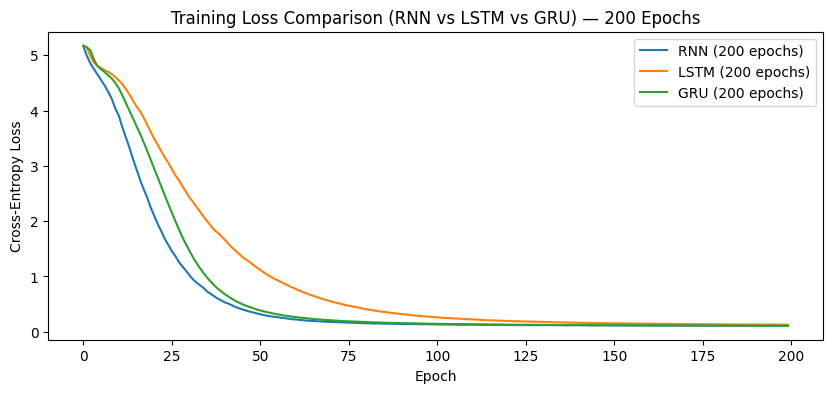

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN (200 epochs)')
plt.plot(lstm_history.history['loss'], label='LSTM (200 epochs)')
plt.plot(gru_history.history['loss'], label='GRU (200 epochs)')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Comparison (RNN vs LSTM vs GRU) — 200 Epochs")
plt.legend()
plt.show()

## 🔁 100 vs 200 Epochs — Training Comparison
This section directly compares the **original 100-epoch requirement** against the **upgraded 200-epoch student task** for each architecture, to see how much additional training actually improves convergence.

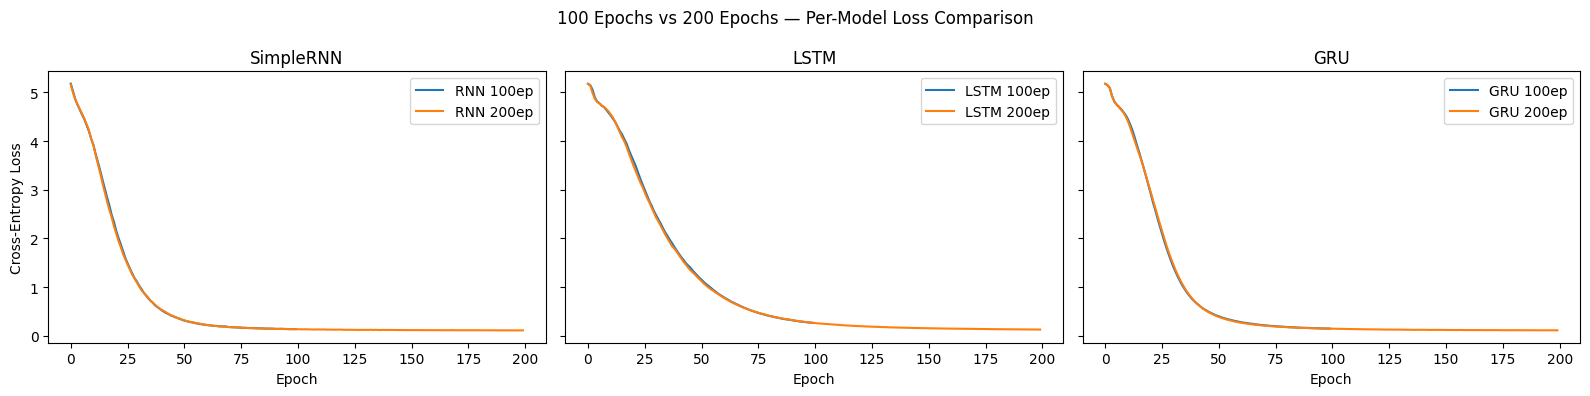

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,4), sharey=True)

axes[0].plot(rnn_history_100.history['loss'], label='RNN 100ep')
axes[0].plot(rnn_history.history['loss'], label='RNN 200ep')
axes[0].set_title('SimpleRNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(lstm_history_100.history['loss'], label='LSTM 100ep')
axes[1].plot(lstm_history.history['loss'], label='LSTM 200ep')
axes[1].set_title('LSTM')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(gru_history_100.history['loss'], label='GRU 100ep')
axes[2].plot(gru_history.history['loss'], label='GRU 200ep')
axes[2].set_title('GRU')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('100 Epochs vs 200 Epochs — Per-Model Loss Comparison')
plt.tight_layout()
plt.show()

In [9]:
final_loss_table = {
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Final Loss @100ep': [rnn_history_100.history['loss'][-1],
                           lstm_history_100.history['loss'][-1],
                           gru_history_100.history['loss'][-1]],
    'Final Loss @200ep': [rnn_history.history['loss'][-1],
                           lstm_history.history['loss'][-1],
                           gru_history.history['loss'][-1]]
}
import pandas as pd
df = pd.DataFrame(final_loss_table)
df['Improvement (%)'] = ((df['Final Loss @100ep'] - df['Final Loss @200ep']) / df['Final Loss @100ep'] * 100).round(2)
df

,Model,Final Loss @100ep,Final Loss @200ep,Improvement (%)
0,RNN,0.135056,0.109559,18.88
1,LSTM,0.263366,0.126863,51.83
2,GRU,0.145415,0.110491,24.02


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [10]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [11]:
print("=== 200-epoch models (upgraded) ===")
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

print("\n=== 100-epoch models (baseline) ===")
print("RNN :", generate_text(rnn_model_100, "deep learning", 10))
print("LSTM:", generate_text(lstm_model_100, "deep learning", 10))
print("GRU :", generate_text(gru_model_100, "deep learning", 10))

=== 200-epoch models (upgraded) ===
RNN : deep learning to sleep perchance to dream—ay there's the rub schoolboy with
LSTM: deep learning more and by opposing end sleep to say we end
GRU : deep learning to be or not to be that is the question

=== 100-epoch models (baseline) ===
RNN : deep learning to be or not to be that is the question
LSTM: deep learning to be or not to be that is the question
GRU : deep learning to sleep perchance to dream—ay there's the rub but infant


#  Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
